# Gemma-2-2B-it 슬롯 추출 — 파인튜닝 전/후 성능 비교

**이 노트북이 하는 일**

하나의 CSV 파일 `data/eval/e2e_recommendation_eval_v1_500.csv` (500행) 만 사용해서 슬롯 추출 모델 파인튜닝 전/후 성능을 비교한다.

1. **데이터 split (8:2)**: 500행 중 무작위 400행 → 훈련용, 100행 → held-out 평가용 (훈련 중 한 번도 모델이 보지 않는 데이터)
2. **Baseline 평가**: raw `google/gemma-2-2b-it` 로 held-out 100행 슬롯 추출 성능 측정
3. **파인튜닝**: 400행 훈련 데이터로 QLoRA (4-bit + LoRA r=32) 로 LoRA 어댑터 학습.
    - ⚠️ 이전 실패 원인 (prompt 토큰에 loss 걸려 model collapse) 해결을 위해 **수동 label masking** — prompt 부분 토큰은 labels=-100 으로 마스킹해서 assistant 응답 부분만 loss 계산
4. **파인튜닝 후 평가**: 어댑터 붙인 모델로 같은 held-out 100행 재평가
5. **비교**: 두 결과 나란히 pandas 표 + 막대그래프로 시각화

**실행 환경**
- n18 GPU 노드 (Tesla V100-32GB) — `ssh n18` 로 접속
- conda env: **`pba_env`** (torch 2.10 + transformers 5.5 + peft 0.19 + bitsandbytes)
- VS Code 에서 노트북 열 때 우측 상단 커널 선택 → `pba_env` 골라주세요
- `.env` 에 `HF_TOKEN=hf_...` 필요 (gemma-2 가 gated)

**산출물**
- `tuning/data/train_split.jsonl` (400 샘플, 훈련용)
- `tuning/data/eval_split.jsonl` (100 샘플, held-out 평가용)
- `models/slot_extractor_gemma_adapter_v3/` (훈련된 LoRA 어댑터)
- `tuning/results/result_baseline_v3.json`, `result_adapter_v3.json` (평가 결과)
- 노트북 하단 표/차트 (비교 시각화)

**예상 소요**: 셋업 수 초 → baseline eval 5~8분 → 훈련 15~25분 → adapter eval 5~8분 → 비교 즉시. **총 약 30~45분**.

## 1. 셋업 — 경로, GPU, HF 토큰 확인

이 셀은 이후 모든 셀에서 쓰일 변수(경로, 모델 ID 등) 를 정의한다. **먼저 한 번 실행**.

In [1]:
# 셋업: 경로 / GPU / HF token / 시스템 프롬프트 로드
import os, sys, json, random, time, gc
from pathlib import Path

# 프로젝트 루트 고정
ROOT = Path('/home/ai_user/team_b2/codus/PBA_AI_Project')
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
print('PROJECT ROOT :', ROOT)

# GPU 확인
import torch
print('CUDA available :', torch.cuda.is_available())
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        p = torch.cuda.get_device_properties(i)
        print(f'  [{i}] {p.name}  {p.total_memory/1024**3:.1f} GB  cc={p.major}.{p.minor}')

# HF 토큰 (.env) 로드 — gemma-2 는 gated 라 필수
HF_TOKEN = None
env_path = ROOT / '.env'
if env_path.exists():
    for line in env_path.read_text(encoding='utf-8').splitlines():
        if line.strip().startswith('HF_TOKEN='):
            HF_TOKEN = line.split('=', 1)[1].strip().strip('"').strip("'")
            os.environ['HF_TOKEN'] = HF_TOKEN
            os.environ['HUGGING_FACE_HUB_TOKEN'] = HF_TOKEN
            break
print('HF_TOKEN loaded:', bool(HF_TOKEN))

# 핵심 상수
EVAL_CSV     = ROOT / 'data' / 'eval' / 'e2e_recommendation_eval_v1_500.csv'
BASE_MODEL   = 'google/gemma-2-2b-it'
TUNING_DIR   = ROOT / 'tuning'
DATA_DIR     = TUNING_DIR / 'data'
RESULTS_DIR  = TUNING_DIR / 'results'
ADAPTER_DIR  = ROOT / 'models' / 'slot_extractor_gemma_adapter_v3'
DATA_DIR.mkdir(exist_ok=True, parents=True)
RESULTS_DIR.mkdir(exist_ok=True, parents=True)
print('EVAL_CSV exists :', EVAL_CSV.exists())
print('ADAPTER_DIR     :', ADAPTER_DIR)

# 슬롯 추출용 시스템 프롬프트 (짧은 버전 — 긴 prompt 는 훈련 비효율 + collapse 유발)
SYSTEM_PROMPT = """너는 한국어 칵테일 취향 슬롯 추출기다. 발화에 명시된 정보만 JSON 으로 출력. 설명 금지.

스키마: {"extracted_slots": {...}}
- current_mood: "good"|"soso"|"bad"|null
- party_purpose: "celebration"|"date"|"business"|"solo"|"hangout"|null
- taste_profile: {"sweet"|"sour"|"bitter"|"body"|"creamy"|"freshness": "zero"|"low"|"medium"|"high"}
- aroma_profile: {"woody"|"minty"|"fruity"|"citrus"|"floral"|"coffee"|"herbal": "zero"|"low"|"medium"|"high"}
- strength_preference: "zero"|"light"|"medium"|"strong"|null
- disliked_bases: ["whiskey"|"gin"|"rum"|"vodka"|"tequila"]
- favorite_drinks: [str]

규칙:
1. 발화에 없는 축은 넣지 말 것.  2. 질문/"모르겠다" → {"extracted_slots":{}}.
3. "강하게"→high, "적당히"→medium, "살짝"→low, "싫어/빼줘"→zero.
4. taste: 단→sweet, 신→sour, 쓴→bitter, 바디→body, 크리미→creamy, 청량/상큼→freshness.
5. aroma: 우디→woody, 민트→minty, 과일/프루티→fruity, 시트러스/레몬→citrus, 꽃→floral, 커피→coffee, 허브→herbal.
6. "강하게" 를 taste/aroma 값으로 쓰면 안 됨 → "high". strength_preference 에만 "strong" 허용.
7. party_purpose: 혼자→solo, 회식→business, 생일/축하→celebration, 데이트→date, 친구모임→hangout."""

print('SYSTEM_PROMPT len (chars):', len(SYSTEM_PROMPT))

PROJECT ROOT : /home/ai_user/team_b2/codus/PBA_AI_Project
CUDA available : True
  [0] Tesla V100-PCIE-32GB  31.7 GB  cc=7.0
HF_TOKEN loaded: True
EVAL_CSV exists : True
ADAPTER_DIR     : /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_gemma_adapter_v3
SYSTEM_PROMPT len (chars): 1005


## 2. 데이터 8:2 split — 훈련 400 / 평가 100

500행을 seed=42 로 셔플 후 8:2 로 나눠 두 파일로 저장한다.
- 훈련용 `train_split.jsonl` 은 messages 포맷 (system + user + assistant) — 파인튜닝이 읽을 수 있는 형식
- 평가용 `eval_split.jsonl` 도 같은 구조로 저장하되, 평가 시에는 gold(assistant 답) 을 정답 비교에만 사용.

**중요**: 훈련과 평가가 같은 CSV 에서 와도 **겹치지 않음** — held-out 100행은 훈련 중 모델이 한 번도 안 봄.

In [2]:
# CSV 500행 → 8:2 split → train/eval JSONL (messages 포맷) 저장
import csv

def csv_row_to_gold_slots(row: dict) -> dict:
    """CSV 행의 gold_* 컬럼들을 합쳐 extracted_slots 로."""
    gold = {}
    for f in ['current_mood', 'party_purpose', 'strength_preference']:
        v = (row.get(f'gold_{f}') or '').strip()
        if v: gold[f] = v
    for f in ['taste_profile', 'aroma_profile']:
        raw = (row.get(f'gold_{f}') or '').strip()
        try: parsed = json.loads(raw) if raw else {}
        except json.JSONDecodeError: parsed = {}
        if parsed: gold[f] = parsed
    for f in ['disliked_bases', 'favorite_drinks']:
        raw = (row.get(f'gold_{f}') or '').strip()
        try: parsed = json.loads(raw) if raw else []
        except json.JSONDecodeError: parsed = []
        if parsed: gold[f] = parsed
    return gold

def build_sample(user_text: str, gold_slots: dict) -> dict:
    """훈련용 messages 포맷 샘플 한 개."""
    return {
        'messages': [
            {'role': 'system',    'content': SYSTEM_PROMPT},
            {'role': 'user',      'content': user_text},
            {'role': 'assistant', 'content': json.dumps({'extracted_slots': gold_slots}, ensure_ascii=False)},
        ]
    }

# CSV 로드
with open(EVAL_CSV, encoding='utf-8') as f:
    rows = [r for r in csv.DictReader(f) if (r.get('user_text') or '').strip()]
print(f'CSV 총 {len(rows)} 행')

# 셔플 + split
random.seed(42)
random.shuffle(rows)
SPLIT = 0.8
n_train = int(len(rows) * SPLIT)
train_rows = rows[:n_train]
eval_rows  = rows[n_train:]
print(f'train: {len(train_rows)}  eval(held-out): {len(eval_rows)}')

# JSONL 저장
def save_jsonl(path: Path, rows: list[dict]):
    with open(path, 'w', encoding='utf-8') as f:
        for r in rows:
            sample = build_sample(r['user_text'].strip(), csv_row_to_gold_slots(r))
            f.write(json.dumps(sample, ensure_ascii=False) + '\n')

TRAIN_JSONL = DATA_DIR / 'train_split.jsonl'
EVAL_JSONL  = DATA_DIR / 'eval_split.jsonl'
save_jsonl(TRAIN_JSONL, train_rows)
save_jsonl(EVAL_JSONL,  eval_rows)
print('저장 →', TRAIN_JSONL.name, '/', EVAL_JSONL.name)

# 첫 샘플 한 번 확인
with open(TRAIN_JSONL, encoding='utf-8') as f:
    first = json.loads(f.readline())
print('\n[훈련 샘플 예시]')
print('user     :', first['messages'][1]['content'][:80], '...')
print('assistant:', first['messages'][2]['content'])

CSV 총 500 행
train: 400  eval(held-out): 100
저장 → train_split.jsonl / eval_split.jsonl

[훈련 샘플 예시]
user     : 부드러운 질감이 살짝 있으면 좋겠어요 바디감이 묵직했으면 좋겠어요 단맛은 과하지 않게 적당하면 좋겠어요 부담 없이 균형 잡힌 도수면 좋겠어요 꽃 ...
assistant: {"extracted_slots": {"party_purpose": "hangout", "strength_preference": "medium", "taste_profile": {"body": "high", "sweet": "medium", "creamy": "medium"}, "aroma_profile": {"floral": "low"}}}


## 3. 공용 함수 — 모델 로드 / 추론 / 평가 지표

아래 함수들은 baseline 평가 / adapter 평가 양쪽에서 쓴다.
- `load_gemma(adapter_path=None)`: 4-bit QLoRA base 로드, 필요시 어댑터 attach
- `hf_generate(...)`: 한 샘플 추론 (Gemma-2 는 system role 미지원이라 system 을 user 앞에 concat)
- `parse_slots / evaluate_sample / aggregate`: 지표 계산
- `run_eval(...)`: held-out 전체 돌려서 집계 반환 + JSON 저장

In [3]:
import sys, os, torch

print(sys.executable)
print("cuda:", torch.cuda.is_available())
print("count:", torch.cuda.device_count())
print("CVD:", os.environ.get("CUDA_VISIBLE_DEVICES"))
print("device:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else None)


/home/ai_user/team_b2/miniconda3/envs/pba_env/bin/python
cuda: True
count: 1
CVD: 1
device: Tesla V100-PCIE-32GB


In [4]:
# 모델 로드 + 추론 + 지표 헬퍼
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig

SCALAR_FIELDS = ['party_purpose', 'strength_preference', 'current_mood']
DICT_FIELDS   = ['taste_profile', 'aroma_profile']
LIST_FIELDS   = ['disliked_bases', 'favorite_drinks']

def load_gemma(adapter_path=None):
    """4-bit Gemma-2-2b-it 로드. adapter_path 주면 LoRA 붙임."""
    bnb = BitsAndBytesConfig(
        load_in_4bit=True,
        bnb_4bit_compute_dtype=torch.float16,
        bnb_4bit_quant_type='nf4',
    )
    tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
    model = AutoModelForCausalLM.from_pretrained(
        BASE_MODEL, token=HF_TOKEN,
        quantization_config=bnb, device_map='auto',
    )
    if adapter_path is not None:
        from peft import PeftModel
        model = PeftModel.from_pretrained(model, str(adapter_path))
        print('✓ adapter attached:', adapter_path)
    model.eval()
    return model, tokenizer

def build_messages_for_infer(user_text: str):
    """Gemma-2 는 system role 미지원 → user 앞에 concat."""
    return [{'role': 'user', 'content': f'{SYSTEM_PROMPT}\n\n---\n\n{user_text}'}]

def hf_generate(model, tokenizer, user_text: str, max_new_tokens: int = 180) -> str:
    msgs = build_messages_for_infer(user_text)
    prompt = tokenizer.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(prompt, return_tensors='pt').to(model.device)
    with torch.no_grad():
        out = model.generate(
            **inputs, max_new_tokens=max_new_tokens,
            do_sample=False, temperature=1.0, top_p=1.0,
            pad_token_id=tokenizer.eos_token_id,
        )
    gen = tokenizer.decode(out[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)
    return gen.strip()

def parse_slots(raw: str) -> dict:
    """생성 텍스트에서 첫 {..} JSON 을 찾아 extracted_slots 반환."""
    raw = raw.strip()
    start = raw.find('{')
    if start == -1: return {}
    depth = 0
    for i, ch in enumerate(raw[start:], start):
        if ch == '{': depth += 1
        elif ch == '}':
            depth -= 1
            if depth == 0:
                try:
                    obj = json.loads(raw[start:i+1])
                    return obj.get('extracted_slots', obj)
                except json.JSONDecodeError:
                    return {}
    return {}

def _dict_overlap(pred, gold):
    def items_set(d):
        return {(k, json.dumps(v, sort_keys=True, ensure_ascii=False)) for k, v in d.items()}
    ps, gs = items_set(pred), items_set(gold)
    tp = len(ps & gs); return tp, len(ps)-tp, len(gs)-tp

def _list_overlap(pred, gold):
    ps, gs = set(pred), set(gold); tp = len(ps & gs)
    return tp, len(ps)-tp, len(gs)-tp

def evaluate_sample(pred, gold):
    out = {}
    for f in SCALAR_FIELDS:
        p, g = pred.get(f), gold.get(f)
        out[f] = {'pred': p, 'gold': g, 'correct': p == g}
    for f in DICT_FIELDS:
        p, g = pred.get(f) or {}, gold.get(f) or {}
        tp, fp, fn = _dict_overlap(p, g)
        out[f] = {'tp': tp, 'fp': fp, 'fn': fn, 'exact': p == g}
    for f in LIST_FIELDS:
        p, g = pred.get(f) or [], gold.get(f) or []
        tp, fp, fn = _list_overlap(p, g)
        out[f] = {'tp': tp, 'fp': fp, 'fn': fn, 'exact': sorted(p) == sorted(g)}
    return out

def aggregate(sample_results):
    n = len(sample_results); agg = {}
    for f in SCALAR_FIELDS:
        # gold 가 있는 샘플만 accuracy 분자/분모에 포함
        hits  = sum(1 for r in sample_results if r[f]['gold'] is not None and r[f]['correct'])
        denom = sum(1 for r in sample_results if r[f]['gold'] is not None)
        agg[f] = {'acc': hits/denom if denom else None, 'hits': hits, 'denom': denom}
    for f in DICT_FIELDS + LIST_FIELDS:
        tp = sum(r[f]['tp'] for r in sample_results)
        fp = sum(r[f]['fp'] for r in sample_results)
        fn = sum(r[f]['fn'] for r in sample_results)
        exact = sum(1 for r in sample_results if r[f]['exact'])
        prec = tp/(tp+fp) if tp+fp else None
        rec  = tp/(tp+fn) if tp+fn else None
        f1   = 2*prec*rec/(prec+rec) if prec and rec else None
        agg[f] = {'exact_match': exact/n, 'precision': prec, 'recall': rec, 'f1': f1,
                   'tp': tp, 'fp': fp, 'fn': fn}
    return agg

def run_eval(model, tokenizer, eval_jsonl: Path, label: str, save_path: Path):
    """held-out JSONL 전체에 대해 추론 + 지표 집계 + JSON 저장."""
    with open(eval_jsonl, encoding='utf-8') as f:
        samples = [json.loads(l) for l in f if l.strip()]
    print(f'[eval-{label}] {len(samples)} 샘플 시작…')
    results = []; errors = 0; t0 = time.time()
    for i, s in enumerate(samples, 1):
        user_text = s['messages'][1]['content']
        gold = json.loads(s['messages'][2]['content']).get('extracted_slots', {})
        try:
            raw = hf_generate(model, tokenizer, user_text)
            pred = parse_slots(raw)
        except Exception as e:
            errors += 1; pred = {}
            print(f'  [{i}] 오류: {e}')
        results.append(evaluate_sample(pred, gold))
        if i % 25 == 0:
            dt = time.time() - t0
            print(f'  {i}/{len(samples)}  ({dt:.0f}s)')
    dt = time.time() - t0
    print(f'[eval-{label}] 완료: {dt:.1f}s  오류 {errors}개')
    result = {
        'label': label, 'base_model': BASE_MODEL, 'n': len(samples),
        'errors': errors, 'elapsed_s': round(dt, 1), 'aggregate': aggregate(results),
    }
    save_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding='utf-8')
    print(f'저장 → {save_path}')
    return result

## 4. Baseline 평가 — raw gemma-2-2b-it

파인튜닝 **전** 모델로 held-out 100 샘플 평가. V100 에서 약 5~8분 예상.

In [5]:
baseline_model, tokenizer = load_gemma(adapter_path=None)
baseline_result = run_eval(
    baseline_model, tokenizer, EVAL_JSONL,
    label='baseline_v3', save_path=RESULTS_DIR / 'result_baseline_v3.json'
)
print('baseline acc (party_purpose):', baseline_result['aggregate']['party_purpose']['acc'])
print('baseline f1  (taste_profile):', baseline_result['aggregate']['taste_profile']['f1'])

# 다음 셀에서 훈련 모델 따로 로드하니까 VRAM 비우기
del baseline_model
gc.collect(); torch.cuda.empty_cache()

Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

[eval-baseline_v3] 100 샘플 시작…
  25/100  (240s)
  50/100  (481s)
  75/100  (708s)
  100/100  (955s)
[eval-baseline_v3] 완료: 955.5s  오류 0개
저장 → /home/ai_user/team_b2/codus/PBA_AI_Project/tuning/results/result_baseline_v3.json
baseline acc (party_purpose): 0.5217391304347826
baseline f1  (taste_profile): 0.28342245989304815


## 5. 파인튜닝 — QLoRA (수동 label masking 으로 collapse 방지)

**이전 실패와의 차이**: 이전엔 prompt(system+user) 토큰에도 loss 가 걸려서 모델이 prompt 내 빈도 높은 단일 토큰("좋", `"`)만 반복하는 **collapse** 에 빠졌음.

**이번 수정**:
- 데이터셋을 **직접 토크나이즈** 하고, prompt 구간의 `labels` 를 `-100` 으로 설정 → loss 계산에서 제외.
- 따라서 모델이 **오직 assistant JSON 응답** 만 학습.
- TRL/Unsloth 우회 — plain `transformers.Trainer` 사용.

**하이퍼파라미터**:
- LoRA r=32, alpha=64, dropout=0.05
- epochs=5, batch=4, grad_accum=4 (effective 16)
- lr=2e-4 (label masking 덕에 올려도 안전)
- warmup 0.1, grad clip 1.0, weight_decay 0.01

**예상 시간**: V100 에서 15~25분

In [6]:
# 훈련용 모델 로드 (4-bit base + LoRA) — peft 직접 사용, Unsloth/TRL 우회
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training

bnb = BitsAndBytesConfig(
    load_in_4bit=True, bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_quant_type='nf4', bnb_4bit_use_double_quant=True,
)
tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL, token=HF_TOKEN)
model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL, token=HF_TOKEN,
    quantization_config=bnb, device_map='auto',
)
model = prepare_model_for_kbit_training(model)

lora_cfg = LoraConfig(
    r=32, lora_alpha=64, lora_dropout=0.05, bias='none', task_type='CAUSAL_LM',
    target_modules=['q_proj','k_proj','v_proj','o_proj','gate_proj','up_proj','down_proj'],
)
model = get_peft_model(model, lora_cfg)
model.print_trainable_parameters()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

trainable params: 41,533,440 || all params: 2,655,875,328 || trainable%: 1.5638


In [7]:
# 훈련 dataset 구성 — prompt 토큰은 labels=-100 으로 마스킹
from datasets import Dataset

MAX_LEN = 1024

def tokenize_with_masked_labels(sample):
    """messages → input_ids + labels(prompt 부분 -100). Gemma-2 system→user concat."""
    msgs = sample['messages']
    if msgs and msgs[0].get('role') == 'system':
        sys_c = msgs[0]['content']
        rest  = msgs[1:]
        if rest and rest[0].get('role') == 'user':
            rest = [
                {'role': 'user', 'content': f"{sys_c}\n\n---\n\n{rest[0]['content']}"},
                *rest[1:],
            ]
        msgs = rest
    assert msgs[-1]['role'] == 'assistant'
    prompt_msgs = msgs[:-1]
    prompt_text = tokenizer.apply_chat_template(prompt_msgs, tokenize=False, add_generation_prompt=True)
    full_text   = tokenizer.apply_chat_template(msgs,        tokenize=False, add_generation_prompt=False)
    prompt_ids = tokenizer(prompt_text, add_special_tokens=False)['input_ids']
    full_ids   = tokenizer(full_text,   add_special_tokens=False)['input_ids']
    full_ids = full_ids[:MAX_LEN]
    n_prompt = min(len(prompt_ids), len(full_ids))
    labels = [-100] * n_prompt + full_ids[n_prompt:]
    return {
        'input_ids': full_ids,
        'attention_mask': [1] * len(full_ids),
        'labels': labels,
    }

# 훈련 데이터 400개 중 90% train / 10% val (학습 중 모니터링용). held-out 100 은 건드리지 않음.
with open(TRAIN_JSONL, encoding='utf-8') as f:
    train_samples = [json.loads(l) for l in f if l.strip()]
random.seed(43)
random.shuffle(train_samples)
n_val = max(1, len(train_samples) // 10)
val_samples   = train_samples[:n_val]
train_samples = train_samples[n_val:]
print(f'train={len(train_samples)}  val={len(val_samples)}')

train_ds = Dataset.from_list(train_samples).map(tokenize_with_masked_labels, remove_columns=['messages'])
val_ds   = Dataset.from_list(val_samples  ).map(tokenize_with_masked_labels, remove_columns=['messages'])

sample0 = train_ds[0]
print('첫 샘플 input_ids 길이:', len(sample0['input_ids']))
print('  labels 중 -100 비율:', sum(1 for x in sample0['labels'] if x == -100) / len(sample0['labels']))

train=360  val=40


Map:   0%|          | 0/360 [00:00<?, ? examples/s]

Map:   0%|          | 0/40 [00:00<?, ? examples/s]

첫 샘플 input_ids 길이: 614
  labels 중 -100 비율: 0.8843648208469055


In [8]:
# 훈련 실행 — transformers.Trainer 직접 사용
from transformers import Trainer, TrainingArguments, DataCollatorForSeq2Seq

training_args = TrainingArguments(
    output_dir=str(ADAPTER_DIR),
    num_train_epochs=5,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,    # effective batch = 16
    learning_rate=2e-4,
    warmup_ratio=0.1,
    lr_scheduler_type='cosine',
    max_grad_norm=1.0,
    weight_decay=0.01,
    fp16=not torch.cuda.is_bf16_supported(),
    bf16=torch.cuda.is_bf16_supported(),
    logging_steps=10,
    eval_strategy='steps',
    eval_steps=25,
    save_strategy='steps',
    save_steps=50,
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,
    seed=42,
    report_to='none',
    remove_unused_columns=False,
)

collator = DataCollatorForSeq2Seq(tokenizer, pad_to_multiple_of=8)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    data_collator=collator,
)
trainer.train()

# 어댑터 저장
model.save_pretrained(str(ADAPTER_DIR))
tokenizer.save_pretrained(str(ADAPTER_DIR))
print('✓ 어댑터 저장:', ADAPTER_DIR)

# 다음 셀에서 adapter 평가용 모델 새로 로드할 거라 VRAM 비우기
del model, trainer
gc.collect(); torch.cuda.empty_cache()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/home/ai_user/team_b2/miniconda3/envs/pba_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)


Step,Training Loss,Validation Loss
25,0.111300,0.068958
50,0.024380,0.036384
75,0.015642,0.027055
100,0.008239,0.023420
115,0.008242,0.023108


/home/ai_user/team_b2/miniconda3/envs/pba_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
/home/ai_user/team_b2/miniconda3/envs/pba_env/lib/python3.10/site-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences bet

✓ 어댑터 저장: /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_gemma_adapter_v3


## 6. Fine-tuned 평가 — 같은 held-out 100 샘플

훈련 끝난 어댑터를 attach 하고 동일한 100개로 평가. V100 에서 5~8분.

In [9]:
adapter_model, tokenizer = load_gemma(adapter_path=ADAPTER_DIR)
adapter_result = run_eval(
    adapter_model, tokenizer, EVAL_JSONL,
    label='adapter_v3', save_path=RESULTS_DIR / 'result_adapter_v3.json'
)
print('adapter acc (party_purpose):', adapter_result['aggregate']['party_purpose']['acc'])
print('adapter f1  (taste_profile):', adapter_result['aggregate']['taste_profile']['f1'])

del adapter_model
gc.collect(); torch.cuda.empty_cache()

Loading weights:   0%|          | 0/288 [00:00<?, ?it/s]

✓ adapter attached: /home/ai_user/team_b2/codus/PBA_AI_Project/models/slot_extractor_gemma_adapter_v3
[eval-adapter_v3] 100 샘플 시작…
  25/100  (194s)
  50/100  (370s)
  75/100  (534s)
  100/100  (694s)
[eval-adapter_v3] 완료: 694.3s  오류 0개
저장 → /home/ai_user/team_b2/codus/PBA_AI_Project/tuning/results/result_adapter_v3.json
adapter acc (party_purpose): 0.9565217391304348
adapter f1  (taste_profile): 0.9863013698630138


## 7. 비교 — Pandas 표

In [10]:
import pandas as pd

def to_df(result, col_name):
    agg = result['aggregate']
    rows = []
    for f in SCALAR_FIELDS:
        rows.append({'field': f, 'metric': 'accuracy',    col_name: agg[f]['acc']})
    for f in DICT_FIELDS + LIST_FIELDS:
        rows.append({'field': f, 'metric': 'exact_match', col_name: agg[f]['exact_match']})
        rows.append({'field': f, 'metric': 'f1',          col_name: agg[f]['f1']})
    return pd.DataFrame(rows)

df = to_df(baseline_result, 'baseline').merge(
        to_df(adapter_result, 'finetuned'), on=['field', 'metric'])
df['delta_pp'] = (df['finetuned'] - df['baseline']) * 100   # 퍼센트 포인트 차이

df_show = df.copy()
for c in ['baseline', 'finetuned']:
    df_show[c] = df_show[c].apply(lambda v: f'{v*100:.1f}%' if v is not None else '—')
df_show['delta_pp'] = df_show['delta_pp'].apply(lambda v: f'{v:+.1f}pp' if pd.notna(v) else '—')
display(df_show)

,field,metric,baseline,finetuned,delta_pp
0,party_purpose,accuracy,52.2%,95.7%,+43.5pp
1,strength_preference,accuracy,23.3%,97.8%,+74.4pp
2,current_mood,accuracy,41.0%,98.0%,+57.0pp
3,taste_profile,exact_match,0.0%,98.0%,+98.0pp
4,taste_profile,f1,28.3%,98.6%,+70.3pp
5,aroma_profile,exact_match,1.0%,99.0%,+98.0pp
6,aroma_profile,f1,20.3%,99.7%,+79.4pp
7,disliked_bases,exact_match,61.0%,100.0%,+39.0pp
8,disliked_bases,f1,41.4%,100.0%,+58.6pp
9,favorite_drinks,exact_match,85.0%,99.0%,+14.0pp


## 8. 비교 — 막대그래프

/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 49836 (\N{HANGUL SYLLABLE SEUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 47215 (\N{HANGUL SYLLABLE ROS}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 52628 (\N{HANGUL SYLLABLE CU}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 54028 (\N{HANGUL SYLLABLE PA}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 51064 (\N{HANGUL SYLLABLE IN}) missing from current font.
  plt.tight_layout(); plt.show()
/tmp/ipykernel_3081231/2587301546.py:17: UserWarning: Glyph 53916 (\N{HANGUL SYLLABLE TYU}

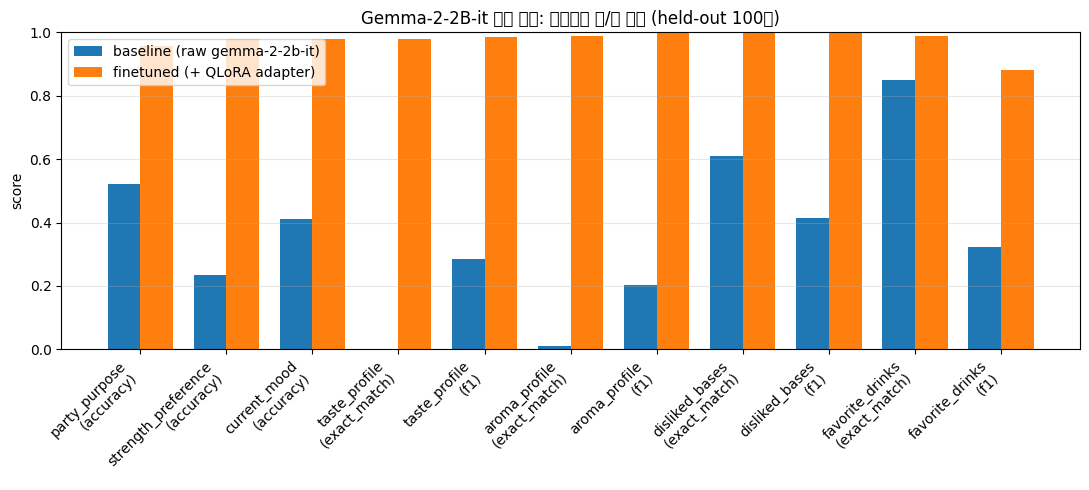

baseline  처리시간:  955.5s
finetuned 처리시간:  694.3s
baseline  오류: 0  /  finetuned 오류: 0


In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11, 5))
labels = [f'{r.field}\n({r.metric})' for r in df.itertuples()]
x = range(len(labels))
w = 0.38
base_vals = [v if v is not None else 0 for v in df['baseline']]
ft_vals   = [v if v is not None else 0 for v in df['finetuned']]
ax.bar([i - w/2 for i in x], base_vals, width=w, label='baseline (raw gemma-2-2b-it)')
ax.bar([i + w/2 for i in x], ft_vals,   width=w, label='finetuned (+ QLoRA adapter)')
ax.set_xticks(list(x))
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_ylabel('score')
ax.set_ylim(0, 1.0)
ax.set_title(f'Gemma-2-2B-it 슬롯 추출: 파인튜닝 전/후 비교 (held-out {baseline_result["n"]}개)')
ax.legend(); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

print(f"baseline  처리시간: {baseline_result['elapsed_s']:>6.1f}s")
print(f"finetuned 처리시간: {adapter_result['elapsed_s']:>6.1f}s")
print(f"baseline  오류: {baseline_result['errors']}  /  finetuned 오류: {adapter_result['errors']}")